In [7]:
import pandas as pd 

df = pd.read_csv('data/rason_complete.csv')

In [9]:
import pandas as pd
import numpy as np


# ── Step 2: Flight metadata — one row per flight_id ─────────────────────────────
flight_meta = (
    df.groupby('flight_id')
    .agg(
        n_levels     = ('pressure_hPa',      'count'),
        burst_pres   = ('pressure_hPa',      'min'),
        max_height   = ('height_m',          'max'),
        min_temp     = ('temp_C',            'min'),
        mean_ascent  = ('ascent_rate_mps',   'mean'),
    )
    .reset_index()
)

# ── Step 3: 30 hPa threshold ─────────────────────────────────────────────────
flight_meta['premature'] = flight_meta['burst_pres'] > 30

print(flight_meta['premature'].value_counts())
print(f"\nTotal flights     : {len(flight_meta)}")
print(f"Nominal  (≤30  hPa): {(~flight_meta['premature']).sum()}")
print(f"Premature (>50 hPa): {flight_meta['premature'].sum()}")

# ── Step 4: Split raw df into premature and nominal ──────────────────────────
premature_ids = flight_meta.loc[flight_meta['premature'],  'flight_id']
nominal_ids   = flight_meta.loc[~flight_meta['premature'], 'flight_id']

df_premature = df[df['flight_id'].isin(premature_ids)].copy()
df_nominal   = df[df['flight_id'].isin(nominal_ids)].copy()

print(f"\nPremature rows : {len(df_premature)}")
print(f"Nominal rows   : {len(df_nominal)}")

premature
False    923
True     738
Name: count, dtype: int64

Total flights     : 1661
Nominal  (≤30  hPa): 923
Premature (>50 hPa): 738

Premature rows : 1263986
Nominal rows   : 2475555


In [10]:
df_premature

,time_s,status_flag,pressure_hPa,height_m,lat_disp,lon_disp,temp_C,dewpoint_C,wind_dir_deg,wind_speed_mps,ascent_rate_mps,latitude,longitude,launch_time,flight_id,hour
5460,0.0,145408.0,1012.7,5.0,0.00000,0.00000,25.00,24.83,77.0,4.0,NaN,-0.89050,131.28583,2025-10-28 11:49:51+00:00,2,11
5461,4.0,0.0,1010.7,22.0,0.00029,-0.00026,24.71,23.43,77.0,4.0,4.25,-0.89021,131.28557,2025-10-28 11:49:51+00:00,2,11
5462,6.0,0.0,1009.5,32.0,0.00028,-0.00038,24.59,23.36,77.0,4.0,5.00,-0.89022,131.28545,2025-10-28 11:49:51+00:00,2,11
5463,10.0,0.0,1007.1,54.0,0.00017,-0.00049,24.45,23.38,77.0,4.0,5.50,-0.89033,131.28534,2025-10-28 11:49:51+00:00,2,11
5464,16.0,0.0,1003.2,87.0,0.00011,-0.00072,24.17,23.15,77.0,4.0,5.50,-0.89039,131.28511,2025-10-28 11:49:51+00:00,2,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3739536,4532.0,0.0,33.5,22978.0,0.03933,-0.34780,-56.96,-87.35,93.0,30.7,4.50,3.99844,108.03787,2026-03-25 11:30:33+00:00,1660,11
3739537,4534.0,30736.0,33.5,22981.0,0.03936,-0.34834,-56.96,-87.35,93.0,30.7,1.50,3.99847,108.03733,2026-03-25 11:30:33+00:00,1660,11
3739538,4536.0,0.0,33.5,22991.0,0.03940,-0.34887,-56.96,-87.35,92.0,30.7,5.00,3.99851,108.03680,2026-03-25 11:30:33+00:00,1660,11
3739539,3029.0,16384.0,127.4,NaN,0.03265,-0.17316,NaN,NaN,NaN,NaN,NaN,3.99176,108.21251,2026-03-25 11:30:33+00:00,1660,11


In [11]:
# Select a random flight ID from the premature group
val_id = premature_ids.sample(2, random_state=44).iloc[0]

print(f"Validation Flight: {val_id}")


Validation Flight: 234


In [12]:
df_test = df_premature[df_premature['flight_id'] == val_id].copy()
df_test = df_test.drop(columns=['flight_id'])

df_premature = df_premature[df_premature['flight_id'] != val_id].copy()

In [85]:
def engineer_features(flight_df):
    f = flight_df.sort_values('pressure_hPa', ascending=False).reset_index(drop=True)

    if len(f) < 3:
        return None

    for col in ['temp_C', 'dewpoint_C', 'wind_speed_mps',
                'height_m', 'ascent_rate_mps']:
        f[col] = pd.to_numeric(f[col], errors='coerce')
        f[col] = f[col].replace([-9999, -999, 9999, 99999], np.nan)

    f['dz']    = f['height_m'].diff().abs()
    f['dspd']  = f['wind_speed_mps'].diff().abs()
    f['dtemp'] = f['temp_C'].diff()
    dz_safe    = f['dz'].replace(0, np.nan)

    f['shear'] = np.where(f['dz'] > 10, f['dspd'] / dz_safe * 100, np.nan)

    g, Gamma_d = 9.81, 9.8 / 1000
    T_K = f['temp_C'] + 273.15
    N2  = (g / T_K) * (f['dtemp'] / dz_safe + Gamma_d)
    S2  = (f['dspd'] / dz_safe) ** 2
    f['Ri'] = N2 / S2.replace(0, np.nan)

    # ── dewpoint depression (spread) — key moisture diagnostic ───────────
    # Small spread = near-saturated air = balloon skin gets wet
    f['dd'] = f['temp_C'] - f['dewpoint_C']  # dewpoint depression (°C)
    # Relative humidity proxy from dewpoint depression
    # Magnus approximation: RH ≈ 100 - 5 * dd (valid for dd < 50°C)
    f['rh_approx'] = (100 - 5 * f['dd']).clip(0, 100)

    # ── ICING flag: supercooled liquid water zone ─────────────────────────
    # Requires sub-zero temperature AND near-saturation
    # Reference: GRUAN 2025 — ice formation on balloon membrane
    f['icing'] = (
        f['temp_C'].between(-20, 0) &
        (f['dd'].abs() < 3) &
        f['dewpoint_C'].notna()
    )

    # ── HEAVY MOISTURE flag: warm saturated layers ────────────────────────
    # Distinct from icing — positive temperature, near-saturated
    # Mechanism: liquid water collecting on latex skin weakens membrane
    # Reference: latex balloon science — prolonged moisture exposure
    # reduces tensile strength (BalloonHQ, Balloon Science 101)
    # Indonesia-specific: deep warm moist layer from maritime convection
    f['heavy_moisture'] = (
        f['temp_C'] > 0 &           # warm — NOT icing territory
        (f['dd'] < 2) &             # near-saturated (RH > ~90%)
        f['dewpoint_C'].notna()
    )

    # ascent rate stats
    ar         = f['ascent_rate_mps'].dropna()
    ar_mean    = ar.mean()
    ar_std     = ar.std() if len(ar) > 1 else np.nan
    burst_alt  = f['height_m'].max()
    near_burst = f[f['height_m'] >= (burst_alt - 2000)]['ascent_rate_mps'].dropna()

    spike_mask = (
        f['ascent_rate_mps'] > (ar_mean + 2 * ar_std)
        if (ar_std and ar_std > 0)
        else pd.Series([False] * len(f))
    )

    burst_pres    = f['pressure_hPa'].min()
    burst_idx     = f['pressure_hPa'].idxmin()
    temp_at_burst = f.loc[burst_idx, 'temp_C']

    shear_idx      = f['shear'].idxmax() if f['shear'].notna().any() else None
    max_shear      = f['shear'].max()
    shear_alt      = f.loc[shear_idx, 'height_m'] if shear_idx is not None else np.nan
    shear_to_burst = (burst_alt - shear_alt) if pd.notna(shear_alt) else np.nan

    ri_idx = f['Ri'].idxmin() if f['Ri'].notna().any() else None
    min_Ri = f['Ri'].min()
    ri_alt = f.loc[ri_idx, 'height_m'] if ri_idx is not None else np.nan

    # icing stats
    icing_levels = f[f['icing']]
    icing_depth  = len(icing_levels) * 50
    icing_index  = (
        icing_levels['temp_C'].abs() *
        icing_levels['dd'].abs()
    ).mean() if len(icing_levels) > 0 else 0.0

    # ── heavy moisture stats ──────────────────────────────────────────────
    moist_levels = f[f['heavy_moisture']]

    # depth of continuous warm saturated layer (m)
    moist_depth  = len(moist_levels) * 50

    # moisture burden index: integrate RH over the saturated depth
    # higher = more cumulative latex stress from moisture exposure
    moist_index  = (
        moist_levels['rh_approx'] *
        (moist_levels['dz'].fillna(50))       # layer thickness weight
    ).sum() if len(moist_levels) > 0 else 0.0

    # mean dewpoint depression in the saturated layer
    # smaller = more saturated = more skin wetting
    moist_dd_mean = moist_levels['dd'].mean() if len(moist_levels) > 0 else np.nan

    # column-integrated precipitable water proxy
    # integral of RH-approx over full profile (not just saturated layers)
    pw_proxy = (f['rh_approx'] * f['dz'].fillna(50)).sum()

    min_temp_idx = f['temp_C'].idxmin() if f['temp_C'].notna().any() else None
    min_temp     = f['temp_C'].min()
    min_temp_alt = f.loc[min_temp_idx, 'height_m'] if min_temp_idx is not None else np.nan


    # Extract hour of launch for time-based features
    flight_hour = f['hour'].iloc[0]

    # Convert hour to coordinates on a 24-hour circle
    hour_sin = np.sin(2 * np.pi * flight_hour / 24)
    hour_cos = np.cos(2 * np.pi * flight_hour / 24)

    return {
        'n_levels'              : len(f),
        'burst_pres_hpa'        : burst_pres,
        'burst_alt_m'           : burst_alt,

        # wind shear
        'max_shear'             : max_shear,
        'shear_alt_m'           : shear_alt,
        'shear_to_burst_m'      : shear_to_burst,
        'bulk_shear_lower'      : f.loc[f['height_m'] <= 6000, 'shear'].mean(),
        'bulk_shear_upper'      : f.loc[f['height_m'] >  6000, 'shear'].mean(),
        'max_wind_speed_mps'    : f['wind_speed_mps'].max(),

        # turbulence
        'ascent_rate_mean'      : ar_mean,
        'ascent_rate_std'       : ar_std,
        'ascent_rate_var_burst' : near_burst.std() if len(near_burst) > 1 else np.nan,
        'ascent_rate_max_spike' : f.loc[spike_mask, 'ascent_rate_mps'].max()
                                  if spike_mask.any() else 0.0,
        'n_turbulent_spikes'    : int(spike_mask.sum()),

        # Richardson
        'min_richardson'        : min_Ri,
        'ri_alt_m'              : ri_alt,
        'n_unstable_layers'     : int((f['Ri'] < 0.25).sum()),

        # icing (sub-zero, near-saturated)
        'icing_depth_m'         : icing_depth,
        'icing_index'           : icing_index,

        # heavy moisture (warm, near-saturated) 
        'moist_depth_m'         : moist_depth,
        'moist_index'           : moist_index,
        'moist_dd_mean'         : moist_dd_mean,
        'pw_proxy'              : pw_proxy,

        # cold tropopause
        'min_temp_C'            : min_temp,
        'min_temp_alt_m'        : min_temp_alt,
        'temp_at_burst_C'       : temp_at_burst,

        #cyclic time features
        'hour_sin': hour_sin,
        'hour_cos': hour_cos,
        'launch_time' : f['launch_time'].iloc[0]
    }


features_list = []
skipped = 0

for fid, group in df_premature.groupby('flight_id'):
    result = engineer_features(group)
    if result is not None:
        features_list.append(result)
    else:
        skipped += 1

feat_df = pd.DataFrame(features_list)
print(f"Processed : {len(feat_df)} flights")
print(f"Skipped   : {skipped}")
print(f"Shape     : {feat_df.shape}")

Processed : 737 flights
Skipped   : 0
Shape     : (737, 29)


In [87]:

def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    feat_clean = df.copy()

    # Fill specific columns with 0
    for col in ['icing_index', 'bulk_shear_upper', 'ascent_rate_max_spike', 'n_turbulent_spikes']:
        if col in feat_clean.columns:
            feat_clean[col] = feat_clean[col].fillna(0)

    # temp_at_burst_C fallback
    if 'temp_at_burst_C' in feat_clean.columns and 'min_temp_C' in feat_clean.columns:
        feat_clean['temp_at_burst_C'] = feat_clean['temp_at_burst_C'].fillna(feat_clean['min_temp_C'])

    # Fill remaining numeric columns with median
    for col in feat_clean.select_dtypes(include=np.number).columns:
        feat_clean[col] = feat_clean[col].fillna(feat_clean[col].median())

    print("Remaining NaNs after cleaning:", feat_clean.isna().sum().sum())
    return feat_clean

feat_clean = clean_features(feat_df)

# ── Step 7: Scale + UMAP ──────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
import umap

feature_cols = [
    'burst_pres_hpa', 
    'max_shear', 'shear_alt_m', 'bulk_shear_upper', 'max_wind_speed_mps',
    'ascent_rate_mean', 'ascent_rate_std', 'ascent_rate_max_spike', 
    'min_richardson','ri_alt_m', 'n_unstable_layers',
    'icing_depth_m', 'icing_index', 
    'moist_depth_m','moist_index','moist_dd_mean','pw_proxy',
    'min_temp_C', 'min_temp_alt_m', 'temp_at_burst_C', 
    #
    #'hour_sin', 'hour_cos'
]

X        = feat_clean[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Remaining NaNs after cleaning: 0


In [89]:
# ── Re-reduce to 5D specifically for clustering ──────────────────────────────
reducer_5d = umap.UMAP(
    n_components = 5,
    n_neighbors  = 20,   # slightly larger neighborhood = smoother density
    min_dist     = 0.0,
    random_state = 42
)
X_5d = reducer_5d.fit_transform(X_scaled)
print("5D UMAP done:", X_5d.shape)

# ── Test grid: both xi and dbscan methods ────────────────────────────────────
from sklearn.cluster import OPTICS

configs = [
    # method,   min_samples, min_cluster_size, xi,   eps
    ('xi',      15,          0.05,             0.05, None),
    ('xi',      25,          0.08,             0.01, None),
    ('xi',      15,          0.05,             0.08, None),
    ('xi',      20,          0.05,             0.08, None),
    ('dbscan',  10,          0.05,             None, 0.5),
    ('dbscan',  10,          0.05,             None, 0.8),
    ('dbscan',  15,          0.05,             None, 0.8),
    ('dbscan',  15,          0.05,             None, 1.0),
    ('dbscan',  20,          0.05,             None, 1.0),
]

print(f"\n{'method':<8} {'min_s':<6} {'xi/eps':<8} {'clusters':<10} {'noise%':<8}")
print("─" * 44)

for method, min_s, min_cs, xi, eps in configs:
    kwargs = dict(
        min_samples      = min_s,
        min_cluster_size = min_cs,
        metric           = 'euclidean',
        cluster_method   = method,
    )
    if method == 'xi':
        kwargs['xi'] = xi
    else:
        kwargs['max_eps'] = eps

    try:
        lbl = OPTICS(**kwargs).fit_predict(X_5d)
        n_cl   = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise  = (lbl == -1).mean() * 100
        marker = " ◄" if (3 <= n_cl <= 6 and noise < 25) else ""
        param  = xi if method == 'xi' else eps
        print(f"{method:<8} {min_s:<6} {param:<8} {n_cl:<10} {noise:.1f}%{marker}")
    except Exception as e:
        print(f"{method:<8} {min_s:<6} — error: {e}")

c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


5D UMAP done: (737, 5)

method   min_s  xi/eps   clusters   noise%  
────────────────────────────────────────────
xi       15     0.05     7          33.1%
xi       25     0.01     7          22.0%
xi       15     0.08     4          72.0%
xi       20     0.08     4          73.4%
dbscan   10     0.5      8          3.4%
dbscan   10     0.8      2          0.0%
dbscan   15     0.8      3          0.1% ◄
dbscan   15     1.0      2          0.0%
dbscan   20     1.0      2          0.0%


In [90]:
# ── Final clustering run ──────────────────────────────────────────────────────
from sklearn.cluster import OPTICS

clusterer = OPTICS(
    min_samples      = 25,
    min_cluster_size = 0.08,
    metric           = 'euclidean',
    cluster_method   = 'xi',
    xi               = 0.01
)
labels = clusterer.fit_predict(X_5d)
feat_clean['cluster'] = labels

print("Final cluster distribution:")
print(feat_clean['cluster'].value_counts().sort_index())
print(f"\nNoise (-1): {(labels == -1).sum()} flights "
      f"({(labels == -1).mean()*100:.1f}%)")

# ── Interpretation: mean feature profile per cluster ─────────────────────────
# These are the columns that carry physical meaning
interp_cols = [
    'burst_pres_hpa', 
    'max_shear', 'shear_alt_m', 'shear_to_burst_m',
    'bulk_shear_lower', 'bulk_shear_upper', 'max_wind_speed_mps',
    'ascent_rate_var_burst', 'n_turbulent_spikes',
    'ri_alt_m', 'n_unstable_layers',
    'icing_depth_m', 'icing_index', 'moist_index','moist_dd_mean',
    'min_temp_C', 'min_temp_alt_m', 'temp_at_burst_C', 'pw_proxy',
]

overall_mean = feat_clean[interp_cols].mean()

print("\n" + "="*70)
print("CLUSTER PROFILES — deviation from overall premature mean")
print("="*70)

for c in sorted(feat_clean['cluster'].unique()):
    subset = feat_clean[feat_clean['cluster'] == c]
    label  = "NOISE" if c == -1 else f"Cluster {c}"
    print(f"\n{label}  (n={len(subset)})")
    print("-" * 50)

    cluster_mean = subset[interp_cols].mean()

    # compute % deviation from overall mean — highlights what's anomalous
    deviation = ((cluster_mean - overall_mean) / overall_mean.abs() * 100).round(1)

    # show top 6 most anomalous features (positive and negative)
    top_high = deviation.nlargest(4)
    top_low  = deviation.nsmallest(4)

    print("  HIGH (above premature average):")
    for feat, val in top_high.items():
        print(f"    {feat:<30} {cluster_mean[feat]:>8.2f}  ({val:+.0f}%)")

    print("  LOW (below premature average):")
    for feat, val in top_low.items():
        print(f"    {feat:<30} {cluster_mean[feat]:>8.2f}  ({val:+.0f}%)")

Final cluster distribution:
cluster
-1    162
 0     88
 1     87
 2     90
 3    109
 4     69
 5     60
 6     72
Name: count, dtype: int64

Noise (-1): 162 flights (22.0%)

CLUSTER PROFILES — deviation from overall premature mean

NOISE  (n=162)
--------------------------------------------------
  HIGH (above premature average):
    shear_to_burst_m                6738.70  (+38%)
    ri_alt_m                        7655.46  (+27%)
    min_temp_alt_m                 14511.30  (+8%)
    n_turbulent_spikes                52.02  (+3%)
  LOW (below premature average):
    burst_pres_hpa                    96.47  (-20%)
    icing_depth_m                   7445.06  (-15%)
    max_wind_speed_mps                24.18  (-14%)
    ascent_rate_var_burst              0.83  (-14%)

Cluster 0  (n=88)
--------------------------------------------------
  HIGH (above premature average):
    icing_depth_m                  16392.61  (+87%)
    pw_proxy                       2809525.63  (+23%)
    min_t

In [113]:
from sklearn.mixture import GaussianMixture

# 1. Define the number of clusters (based on your OPTICS discovery, e.g., 6)
n_clusters = 7

# 2. Initialize and Fit the GMM on your 5D UMAP space
gmm = GaussianMixture(
    n_components=n_clusters, 
    covariance_type='full', 
    random_state=42
)
gmm.fit(X_5d)

# 3. Label your current data
feat_clean['cluster'] = gmm.predict(X_5d)

# 4. (Optional) Check the confidence of the labels
feat_clean['cluster_probs'] = np.max(gmm.predict_proba(X_5d), axis=1)

print("GMM Cluster distribution:")
print(feat_clean['cluster'].value_counts().sort_index())

GMM Cluster distribution:
cluster
0     56
1    149
2     94
3    153
4    117
5    107
6     61
Name: count, dtype: int64


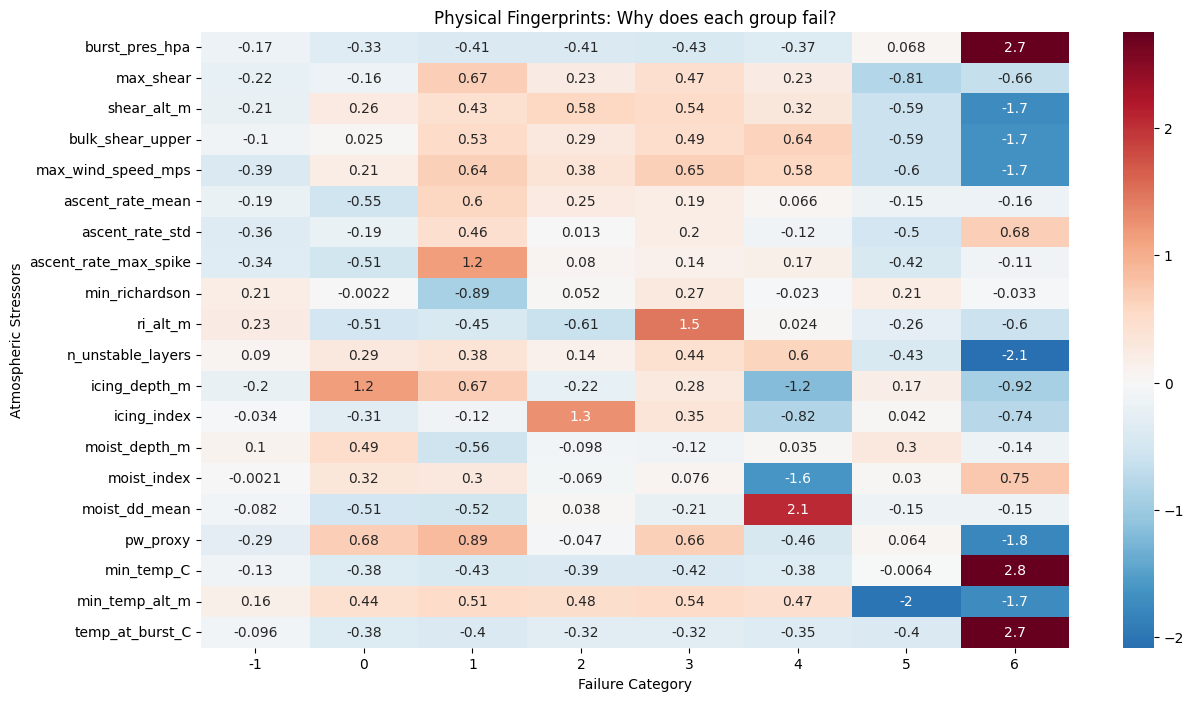

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns


# ── 2. The "Physical Fingerprint": Z-Score Heatmap ────────────────────────────
# This tells you the specific weather stressors for each cluster
cluster_profile = feat_clean.groupby('cluster')[feature_cols].mean()
# Standardize by training set stats (Z-Score)
cluster_z_scores = (cluster_profile - feat_clean[feature_cols].mean()) / feat_clean[feature_cols].std()

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_z_scores.T, cmap='RdBu_r', annot=True, center=0)
plt.title("Physical Fingerprints: Why does each group fail?")
plt.ylabel("Atmospheric Stressors")
plt.xlabel("Failure Category")
plt.show()



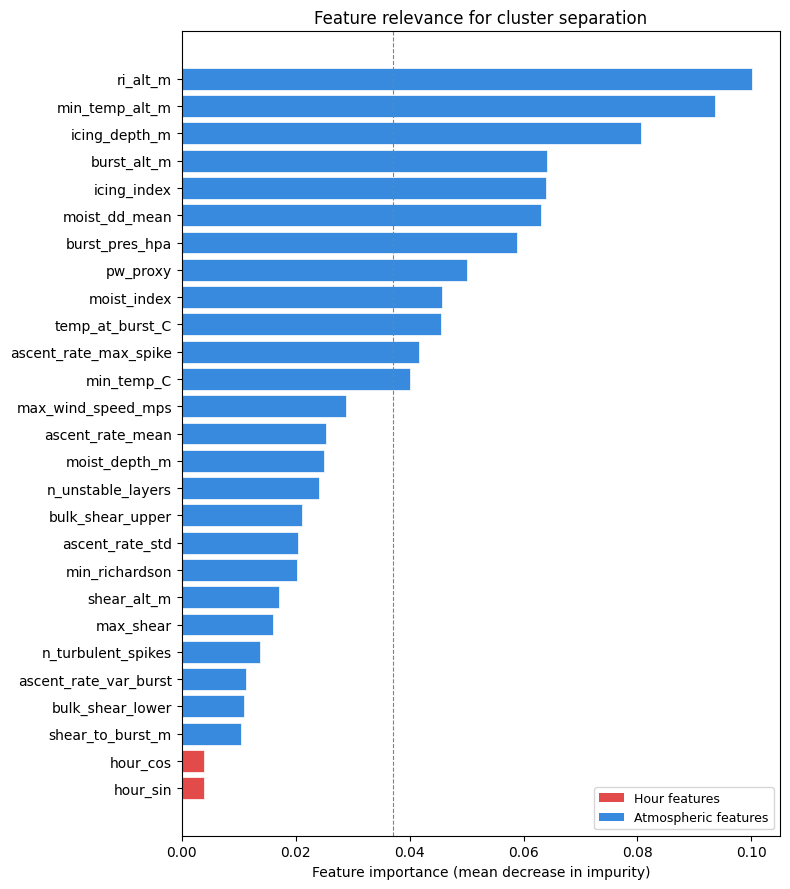


Top 10 most important features:
        feature  importance
temp_at_burst_C    0.045596
    moist_index    0.045739
       pw_proxy    0.050064
 burst_pres_hpa    0.058931
  moist_dd_mean    0.063008
    icing_index    0.063921
    burst_alt_m    0.064122
  icing_depth_m    0.080622
 min_temp_alt_m    0.093663
       ri_alt_m    0.100009

Hour feature importance:
 feature  importance
hour_sin    0.003854
hour_cos    0.004015

Features below mean importance (candidates to drop):
['hour_sin', 'hour_cos', 'shear_to_burst_m', 'bulk_shear_lower', 'ascent_rate_var_burst', 'n_turbulent_spikes', 'max_shear', 'shear_alt_m', 'min_richardson', 'ascent_rate_std', 'bulk_shear_upper', 'n_unstable_layers', 'moist_depth_m', 'ascent_rate_mean', 'max_wind_speed_mps']


In [92]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Use only labeled flights (exclude noise)
labeled = feat_clean[feat_clean['cluster'] >= 0].copy()

feature_cols_with_hour = [
    'burst_pres_hpa', 'burst_alt_m',
    'max_shear', 'shear_alt_m', 'shear_to_burst_m',
    'bulk_shear_lower', 'bulk_shear_upper', 'max_wind_speed_mps',
    'ascent_rate_mean', 'ascent_rate_std',
    'ascent_rate_var_burst', 'ascent_rate_max_spike', 'n_turbulent_spikes',
    'min_richardson', 'ri_alt_m', 'n_unstable_layers',
    'icing_depth_m', 'icing_index',
    'moist_depth_m', 'moist_index', 'moist_dd_mean', 'pw_proxy',
    'min_temp_C', 'min_temp_alt_m', 'temp_at_burst_C',
    'hour_sin', 'hour_cos',   # included to test importance
]

X_imp = labeled[feature_cols_with_hour].fillna(0).values
y_imp = labeled['cluster'].values

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_imp, y_imp)

importance_df = pd.DataFrame({
    'feature'   : feature_cols_with_hour,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#E24B4A' if 'hour' in f else '#378ADD'
          for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Feature relevance for cluster separation')
ax.axvline(importance_df['importance'].mean(), color='gray',
           linestyle='--', linewidth=0.8, label='mean importance')
ax.legend(fontsize=9)

# Add color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E24B4A', label='Hour features'),
                   Patch(facecolor='#378ADD', label='Atmospheric features')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
print(importance_df.tail(10)[['feature','importance']].to_string(index=False))

print("\nHour feature importance:")
hour_imp = importance_df[importance_df['feature'].isin(['hour_sin','hour_cos'])]
print(hour_imp[['feature','importance']].to_string(index=False))

print("\nFeatures below mean importance (candidates to drop):")
below_mean = importance_df[importance_df['importance'] < importance_df['importance'].mean()]
print(below_mean['feature'].tolist())

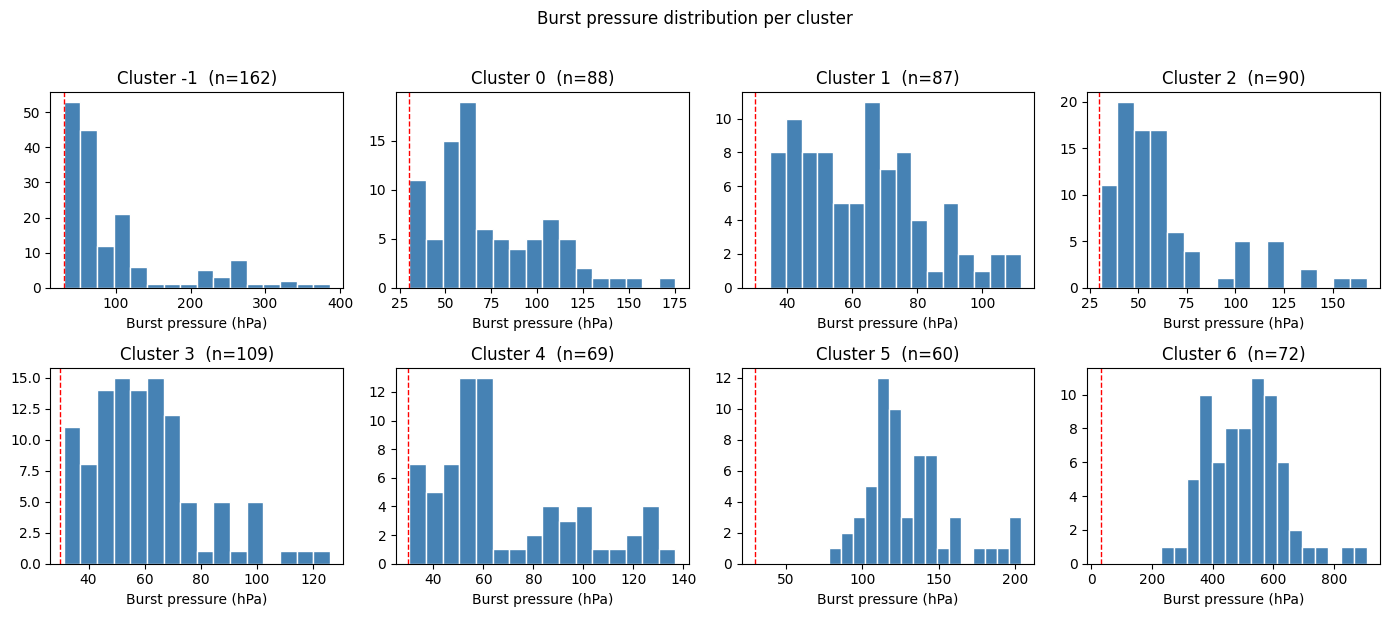

In [93]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, c in enumerate(sorted(feat_clean['cluster'].unique())):
    sub = feat_clean[feat_clean['cluster'] == c]
    axes[i].hist(sub['burst_pres_hpa'], bins=16, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Cluster {c}  (n={len(sub)})')
    axes[i].set_xlabel('Burst pressure (hPa)')
    axes[i].axvline(30, color='red', linewidth=1, linestyle='--', label='30 hPa')

plt.suptitle('Burst pressure distribution per cluster', y=1.02)
plt.tight_layout()
plt.savefig('burst_pressure_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
label_map = {
    -1 : 'unknown_premature',   # exclude from training
     0 : 'deep_icing_layer',
     1 : 'high_updraft',
     2 : 'severe_icing',
     3 : 'atmospheric_instability',
     4 : 'dry_layer',
     5 : 'premature_cold',
     6 : 'launch_failure',
}
feat_clean['cause'] = feat_clean['cluster'].map(label_map)

# ── CREATE FINAL TRAINING DATASET ────────────────────────────────────────────
# Just drop the unknown noise. No nominal data needed!
train_df = feat_clean[feat_clean['cause'] != 'unknown_premature'].copy()

print("\nFinal training dataset (Premature ONLY):")
print(train_df['cause'].value_counts())
print(f"\nTotal: {len(train_df)} flights")


Final training dataset (Premature ONLY):
cause
atmospheric_instability    109
severe_icing                90
deep_icing_layer            88
high_updraft                87
launch_failure              72
dry_layer                   69
premature_cold              60
Name: count, dtype: int64

Total: 575 flights


Classes: ['atmospheric_instability', 'deep_icing_layer', 'dry_layer', 'high_updraft', 'launch_failure', 'premature_cold', 'severe_icing']

5-fold CV F1 (weighted): 0.910 ± 0.012


c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:29:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification report (held-out test set):
                         precision    recall  f1-score   support

atmospheric_instability       0.87      1.00      0.93        20
       deep_icing_layer       0.80      0.67      0.73         6
              dry_layer       1.00      0.89      0.94        28
           high_updraft       0.94      0.85      0.89        20
         launch_failure       1.00      1.00      1.00        10
         premature_cold       1.00      1.00      1.00        14
           severe_icing       0.85      1.00      0.92        17

               accuracy                           0.93       115
              macro avg       0.92      0.92      0.92       115
           weighted avg       0.94      0.93      0.93       115



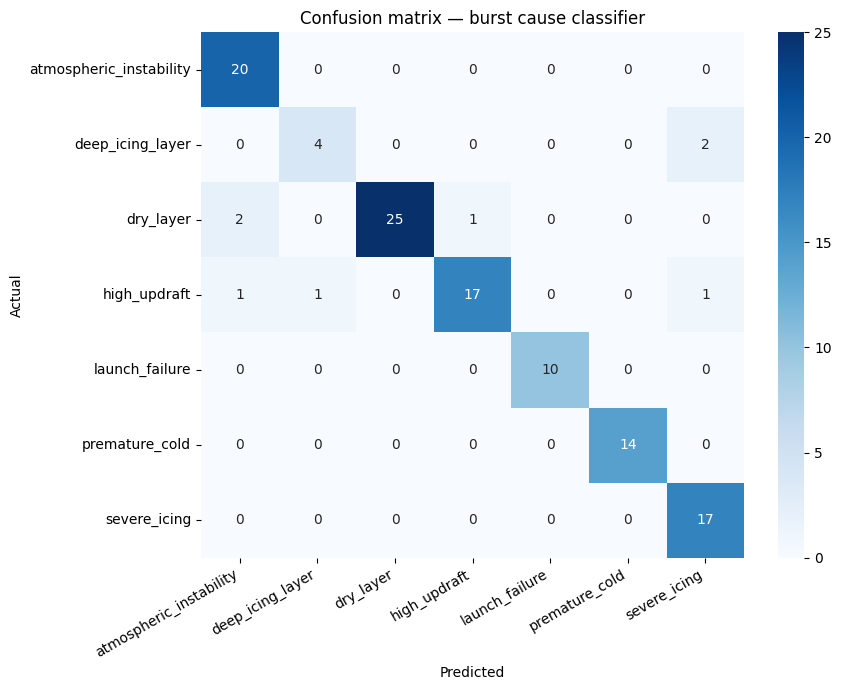

In [97]:
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

os.makedirs('models', exist_ok=True)

# ── Define final feature set ──────────────────────────────────────────────────

feature_cols_final = [
                        'burst_pres_hpa', 
                        'max_shear', 'shear_alt_m', 'bulk_shear_upper', 'max_wind_speed_mps',
                        'ascent_rate_mean', 'ascent_rate_std', 'ascent_rate_max_spike', 
                        'min_richardson','ri_alt_m', 'n_unstable_layers',
                        'icing_depth_m', 'icing_index', 
                        'moist_depth_m','moist_index','moist_dd_mean','pw_proxy',
                        'min_temp_C', 'min_temp_alt_m', 'temp_at_burst_C', 
                        #'hour_sin', 'hour_cos'
                    ]

X = train_df[feature_cols_final].fillna(0).values
y = train_df['cause'].values

# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", list(le.classes_))

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Cross-validation to check quality before final fit ───────────────────────
clf_cv = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 max_depth=10, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf_cv, X_scaled, y_enc, cv=cv,
                             scoring='f1_weighted', n_jobs=-1)
print(f"\n5-fold CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Time-based train/test split ───────────────────────────────────────────────
# Sort by launch_time so test set is always the most recent flights
train_df_sorted = train_df.sort_values('launch_time').reset_index(drop=True)
split_idx = int(len(train_df_sorted) * 0.8)
train_set = train_df_sorted.iloc[:split_idx]
test_set  = train_df_sorted.iloc[split_idx:]

X_train = scaler.transform(train_set[feature_cols_final].fillna(0).values)
X_test  = scaler.transform(test_set[feature_cols_final].fillna(0).values)
y_train = le.transform(train_set['cause'].values)
y_test  = le.transform(test_set['cause'].values)

# ── Final model: XGBoost ──────────────────────────────────────────────────────
clf = XGBClassifier(
    n_estimators        = 400,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    use_label_encoder   = False,
    eval_metric         = 'mlogloss',
    random_state        = 42,
    n_jobs              = -1,
)
clf.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = clf.predict(X_test)
print("\nClassification report (held-out test set):")
print(classification_report(y_test, y_pred,
                             target_names=le.classes_, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — burst cause classifier')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



In [98]:
# ── Save everything ───────────────────────────────────────────────────────────
# Refit on ALL data before saving
clf_final = XGBClassifier(
    n_estimators        = 400,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    use_label_encoder   = False,
    eval_metric         = 'mlogloss',
    random_state        = 42,
    n_jobs              = -1,
)
clf_final.fit(X_scaled, y_enc)

joblib.dump(clf_final,          'models/burst_classifier_model.joblib')
joblib.dump(scaler,             'models/burst_classifier_scaler.joblib')
joblib.dump(le,                 'models/burst_label_encoder.joblib')
joblib.dump(feature_cols_final, 'models/feature_cols.joblib')
joblib.dump(label_map,          'models/label_map.joblib')

print("\nSaved to models/:")
for f in ['burst_classifier_model.joblib', 'burst_classifier_scaler.joblib',
          'burst_label_encoder.joblib', 'feature_cols.joblib', 'label_map.joblib']:
    print(f"  {f}")

c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:31:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Saved to models/:
  burst_classifier_model.joblib
  burst_classifier_scaler.joblib
  burst_label_encoder.joblib
  feature_cols.joblib
  label_map.joblib


In [116]:
def classify_prepared_data(df, feature_cols, scaler, reducer_5d, gmm):

    # --- Step 1: Engineer features ---
    val_raw_dict = engineer_features(df)
    
    # --- Step 2: Clean features ---
    val_feat_clean = clean_features(pd.DataFrame([val_raw_dict]))
    
    # --- Step 3: Prepare array in correct column order ---
    X_cleaned = val_feat_clean[feature_cols].values
    
    # --- Step 4: Scale and UMAP transform ---
    X_val_scaled = scaler.transform(X_cleaned)
    X_val_5d = reducer_5d.transform(X_val_scaled)
    
    # --- Step 5: Predict ---
    predicted_label = gmm.predict(X_val_5d)[0]
    confidence = np.max(gmm.predict_proba(X_val_5d))
    
    return predicted_label, confidence, val_feat_clean

In [126]:
# ── Assign labels ─────────────────────────────────────────────────────────────
label_map = {
    0: "Mechanical (Shear)",                   # Cluster 0
    1: "Dynamic Instability",                # Cluster 1
    2: "Early Launch Failure",    # Cluster 2
    3: "Deep Moist Convection",     # Cluster 3
    4: "Dry Cooling",   # Cluster 4
    5: "Microphysical Icing",                       # Cluster 5
    6: "Shallow Cold Layer"
}

pred_idx, conf, val_feat_clean = classify_prepared_data(
    df=df_test,
    feature_cols=feature_cols,
    scaler=scaler,
    reducer_5d=reducer_5d,
    gmm=gmm
)


# --- 5. Output Results with Physical Explanations ---
print(f"--- Validation Result for Flight {val_id} ---")
print(f"Predicted Category : {label_map[pred_idx]}")
print(f"Model Confidence   : {conf:.2%}")
print("-" * 45)

# Extract Z-scores for this flight to help with the explanation
# (Comparing this flight to the training set distribution)
val_z_scores = (val_feat_clean[feature_cols] - feat_clean[feature_cols].mean()) / feat_clean[feature_cols].std()
if pred_idx == 0:
    print("Explanation: MECHANICAL FAILURE (SHEAR-INDUCED RUPTURE)")
    print("Analysis: Balloon encountered strong vertical wind shear near burst altitude.")
    print("Key Signals:")
    print(f"  - Shear-to-burst distance: {val_z_scores['shear_to_burst_m'].values[0]:.2f} SD (shear close to burst)")
    print(f"  - Max shear: {val_z_scores['max_shear'].values[0]:.2f} SD (elevated)")
    print("Interpretation: Balloon likely ruptured due to mechanical stress from sharp wind gradients.")

elif pred_idx == 1:
    print("Explanation: DYNAMIC INSTABILITY (ALOFT TURBULENCE)")
    print("Analysis: Balloon reached higher altitude and encountered instability layers.")
    print("Key Signals:")
    print(f"  - Richardson instability altitude: {val_feat_clean['ri_alt_m'].values[0]:.0f} m (high altitude)")
    print(f"  - Burst pressure: {val_feat_clean['burst_pres_hpa'].values[0]:.1f} hPa (low → high altitude)")
    print("Interpretation: Failure likely caused by turbulence or dynamic instability in the upper atmosphere.")

elif pred_idx == 2:
    print("Explanation: EARLY LAUNCH / LOW-ALTITUDE FAILURE")
    print("Analysis: Balloon failed prematurely at low altitude under high pressure conditions.")
    print("Key Signals:")
    print(f"  - Burst altitude: {val_feat_clean['burst_alt_m'].values[0]:.1f} m (low)")
    print(f"  - Burst pressure: {val_feat_clean['burst_pres_hpa'].values[0]:.1f} hPa (high)")
    print(f"  - Temperature at burst: {val_feat_clean['temp_at_burst_C'].values[0]:.1f} °C (warm)")
    print(f"  - Max wind speed: {val_feat_clean['max_wind_speed_mps'].values[0]:.1f} m/s (low)")
    print("Interpretation: Failure likely due to launch stress or material weakness, not atmospheric forcing.")

elif pred_idx == 3:
    print("Explanation: DEEP MOIST CONVECTION (MOISTURE-DRIVEN FAILURE)")
    print("Analysis: Balloon ascended through a deep moist atmospheric column.")
    print("Key Signals:")
    print(f"  - Icing depth: {val_z_scores['icing_depth_m'].values[0]:.2f} SD (high)")
    print(f"  - Precipitable water proxy: {val_z_scores['pw_proxy'].values[0]:.2f} SD (high)")
    print("Interpretation: Failure likely linked to strong moisture loading, cloud processes, or embedded convection.")

elif pred_idx == 4:
    print("Explanation: DRY COLD REGIME (NON-ICING THERMODYNAMIC STRESS)")
    print("Analysis: Balloon operated in a dry atmosphere with low moisture and no icing support.")
    print("Key Signals:")
    print(f"  - Icing index: {val_z_scores['icing_index'].values[0]:.2f} SD (low)")
    print(f"  - Moisture index: {val_z_scores['moist_index'].values[0]:.2f} SD (low)")
    print(f"  - Dewpoint depression: {val_feat_clean['moist_dd_mean'].values[0]:.2f} °C (dry air)")
    print("Interpretation: Failure likely due to cold, dry conditions causing material brittleness (not icing).")

elif pred_idx == 5:
    print("Explanation: MICROPHYSICAL ICING (SUPERCOOLED WATER)")
    print("Analysis: Balloon encountered localized icing conditions.")
    print("Key Signals:")
    print(f"  - Icing index: {val_z_scores['icing_index'].values[0]:.2f} SD (high)")
    print("Interpretation: Failure likely due to ice accumulation on the balloon surface.")

elif pred_idx == 6:
    print("Explanation: SHALLOW COLD LAYER (EARLY THERMODYNAMIC STRESS)")
    print("Analysis: Coldest layer occurs unusually low in the atmosphere.")
    print("Key Signals:")
    print(f"  - Min temperature altitude: {val_feat_clean['min_temp_alt_m'].values[0]:.1f} m (lower than normal)")
    print(f"  - Min temperature: {val_feat_clean['min_temp_C'].values[0]:.1f} °C")
    print("Interpretation: Balloon experienced early cold stress before reaching typical high-altitude conditions.")

print("-" * 45)

print(f"--- Flight {val_id} Vertical Stats ---")
print(f"Burst Altitude : {val_feat_clean['burst_alt_m'].values[0]:.2f} m")
print(f"Burst Pressure : {val_feat_clean['burst_pres_hpa'].values[0]:.2f} hPa")


Remaining NaNs after cleaning: 0
--- Validation Result for Flight 234 ---
Predicted Category : Dynamic Instability
Model Confidence   : 100.00%
---------------------------------------------
Explanation: DYNAMIC INSTABILITY (ALOFT TURBULENCE)
Analysis: Balloon reached higher altitude and encountered instability layers.
Key Signals:
  - Richardson instability altitude: 14105 m (high altitude)
  - Burst pressure: 72.9 hPa (low → high altitude)
Interpretation: Failure likely caused by turbulence or dynamic instability in the upper atmosphere.
---------------------------------------------
--- Flight 234 Vertical Stats ---
Burst Altitude : 18421.00 m
Burst Pressure : 72.90 hPa


In [127]:
df_test.to_csv("example_flight_data.csv", index=False)

In [119]:
import joblib

medians = feat_clean.median(numeric_only=True)

pipeline = {
    "scaler": scaler,
    "umap": reducer_5d,
    "gmm": gmm,
    "feature_cols": feature_cols,
    "medians": medians
}

joblib.dump(pipeline, "flight_classifier.pkl")

['flight_classifier.pkl']

In [122]:
print(df_test.head())

         time_s  status_flag  pressure_hPa  height_m  lat_disp  lon_disp  \
1578472     0.0     145408.0        1010.6       7.0   0.00000   0.00000   
1578473     2.0          0.0        1008.4      26.0   0.00000   0.00005   
1578474     4.0          0.0        1006.8      40.0   0.00003   0.00004   
1578475     6.0          0.0        1005.4      53.0   0.00000   0.00002   
1578476     8.0          0.0        1004.3      62.0  -0.00006   0.00011   

         temp_C  dewpoint_C  wind_dir_deg  wind_speed_mps  ascent_rate_mps  \
1578472   27.00       26.83         292.0             1.5              NaN   
1578473   26.62       25.62         291.0             1.7              9.5   
1578474   26.34       25.34         291.0             1.8              7.0   
1578475   26.21       25.32         292.0             1.9              6.5   
1578476   26.09       25.31         294.0             2.0              4.5   

         latitude  longitude  
1578472   3.32705  117.57047  
1578473   3.